# Simple Visualizer for S2 datasets

In [6]:
import rasterio
import numpy as np
import torch
import matplotlib.pyplot as plt
import pathlib
import shapely
import fiona.transform
from mpl_toolkits.basemap import Basemap
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd

from datetime import datetime
from zoneinfo import ZoneInfo
from timezonefinder import TimezoneFinder

In [14]:
USE_COLOR_NORMALIZATION_PERCENT = True

def get_example_image(path, plot=True):
    """
    Loads example Sentinel-2 image from path to tif file
    :param path: Path to image file
    :param plot: If True, will plot an RGB image of the satellite image
    :return: Normalized image as torch tensor
    """
    with rasterio.open(path) as f:
            data = f.read().astype(np.float32)
            image = data / 10000.0
            B10 = np.zeros((1, *image.shape[1:]), dtype=image.dtype)
            image = np.concatenate([image[:10], B10, image[10:]], axis=0)
            image = torch.tensor(image)

            if plot:
                    # Read the first three RGB bands (assuming they are bands 4, 3, and 2)

                    if USE_COLOR_NORMALIZATION_PERCENT:
                        low = 0.02*np.max([np.max(f.read(4)), np.max(f.read(3)), np.max(f.read(2))])
                        high = 0.98*np.max([np.max(f.read(4)), np.max(f.read(3)), np.max(f.read(2))])

                        red_band = ((np.clip(f.read(4), low, high) - low) / (high-low) * 255).astype(np.uint8)
                        green_band = ((np.clip(f.read(3), low, high) - low) / (high-low) * 255).astype(np.uint8)
                        blue_band = ((np.clip(f.read(2), low, high) - low) / (high-low) * 255).astype(np.uint8)
                    else:
                        red_band = f.read(4) / 10000.0
                        green_band = f.read(3) / 10000.0
                        blue_band = f.read(2) / 10000.0

                    # Stack the bands to create an RGB image
                    rgb_image = np.stack([red_band, green_band, blue_band], axis=-1)

                    # Plot the RGB image
                    plt.imshow(rgb_image)
                    plt.title("RGB Sentinel-2 Image")
                    plt.axis('off')  # Hide axes
                    plt.show()

    return image

def get_metadata(path):
    """
    Loads metadata from a Sentinel-2 image file
    :param path: Path to image file
    :return: Metadata dictionary
    """
    tags = {}

    with rasterio.open(path) as src:
        geom = shapely.geometry.mapping(shapely.geometry.box(*src.bounds))
        warped_geom = fiona.transform.transform_geom(src.crs, "EPSG:4326", geom)
        shape = shapely.geometry.shape(warped_geom)
        x, y = shape.centroid.xy
        x = x[0]
        y = y[0]
        tags = src.tags()
        filename = pathlib.Path(path).name
        t = src.tags().get("datetime")
        id = src.tags().get("granule_id")

    return id, x, y, t, tags

In [15]:
def convert_utc_to_local(t, x, y):
    tf = TimezoneFinder()
    iso_string = t # UTC time
    lat, lng = y, x

    timezone_name = tf.timezone_at(lng=lng, lat=lat)

    utc_dt = datetime.fromisoformat(iso_string.replace('Z', '+00:00'))
    
    local_dt = utc_dt.astimezone(ZoneInfo(timezone_name))
        
    return local_dt.isoformat()

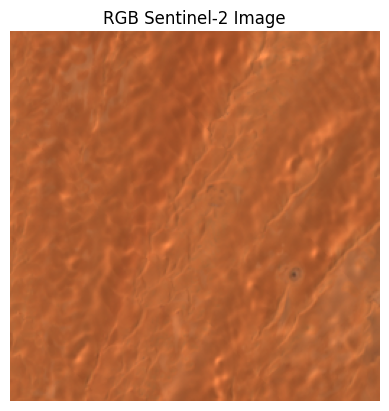

metadata for /media/volume/satclip-datasets/Datasets/ts-satclip-s2-1M/images/2021/patch_S2A_MSIL2A_20211002T090811_R050_T34RCN_20211002T214515.tif:
  id: S2B_OPER_MSI_L2A_TL_ESRI_20210524T211037_A021440_T35QLG_N03.00
UTC data: 
    x: 25.95194320535059
    y: 24.166726347979495
    t: 2021-04-14T08:45:59.024000+00:00
Sanity checking: 
    C/P in Google Maps (lat, lon): (24.166726347979495, 25.95194320535059)
    Local time: 2021-04-14T10:45:59.024000+02:00


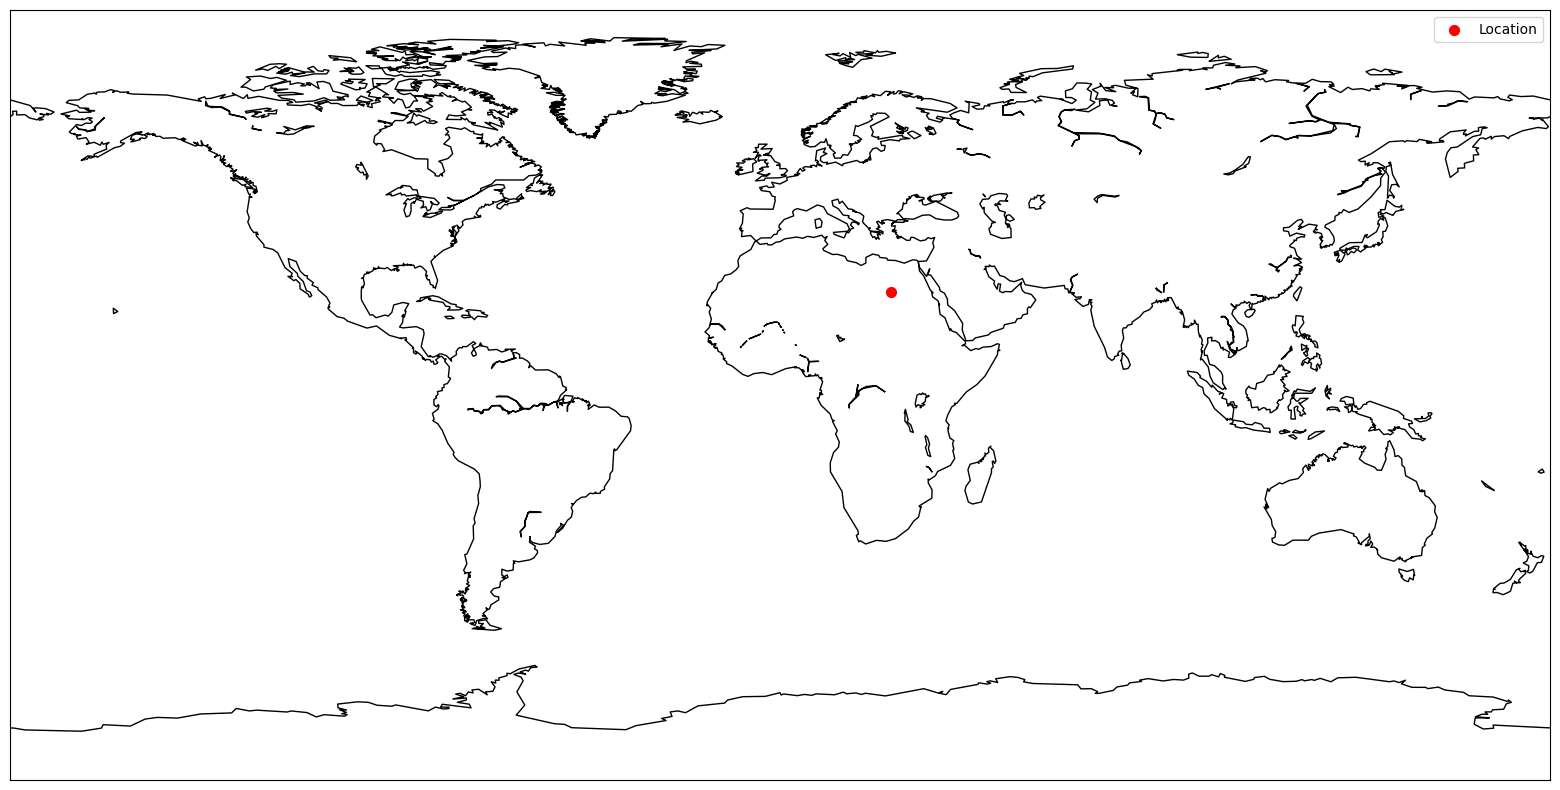

In [16]:
# path = "/mnt/rolf-datastore/home/leca5365/Datasets/satclip-s2-temporal-55k/images/patch_30.tif"
# path = "/home/leca5365/Datasets/satclip-s2-temporal-55k/images/patch_10038.tif"
path = "/media/volume/satclip-datasets/Datasets/ts-satclip-s2-1M/images/2021/patch_S2A_MSIL2A_20211002T090811_R050_T34RCN_20211002T214515.tif"
# print example image
img = get_example_image(path, plot=True)

# print metadata
id, x, y, t, tags = get_metadata(path)

print(f"metadata for {path}:")
print(f"  id: {id}")

print("UTC data: ")
print(f"    x: {x}")
print(f"    y: {y}")
print(f"    t: {t}")

print("Sanity checking: ")
print(f"    C/P in Google Maps (lat, lon): {y, x}")
print(f"    Local time: {convert_utc_to_local(t, x, y)}")

#Plot true and predicted locations
fig, ax = plt.subplots(1,1, figsize=(20, 10))

m = Basemap(projection='cyl', resolution='c', ax=ax)
m.drawcoastlines()
ax.scatter(x, y, s=50, c="red", label="Location")
ax.legend()

Local Time: 2022-05-31T11:26:29.024000+12:00 in Asia/Anadyr


  1%|          | 1098/100000 [00:20<28:50, 57.14it/s]/tmp/ipykernel_5595/3749083296.py:30: RuntimeWarning: invalid value encountered in divide
  red_band = ((np.clip(f.read(4), low, high) - low) / (high-low) * 255).astype(np.uint8)
/tmp/ipykernel_5595/3749083296.py:30: RuntimeWarning: invalid value encountered in cast
  red_band = ((np.clip(f.read(4), low, high) - low) / (high-low) * 255).astype(np.uint8)
/tmp/ipykernel_5595/3749083296.py:31: RuntimeWarning: invalid value encountered in divide
  green_band = ((np.clip(f.read(3), low, high) - low) / (high-low) * 255).astype(np.uint8)
/tmp/ipykernel_5595/3749083296.py:31: RuntimeWarning: invalid value encountered in cast
  green_band = ((np.clip(f.read(3), low, high) - low) / (high-low) * 255).astype(np.uint8)
/tmp/ipykernel_5595/3749083296.py:32: RuntimeWarning: invalid value encountered in divide
  blue_band = ((np.clip(f.read(2), low, high) - low) / (high-low) * 255).astype(np.uint8)
/tmp/ipykernel_5595/3749083296.py:32: RuntimeWarnin

KeyboardInterrupt: 

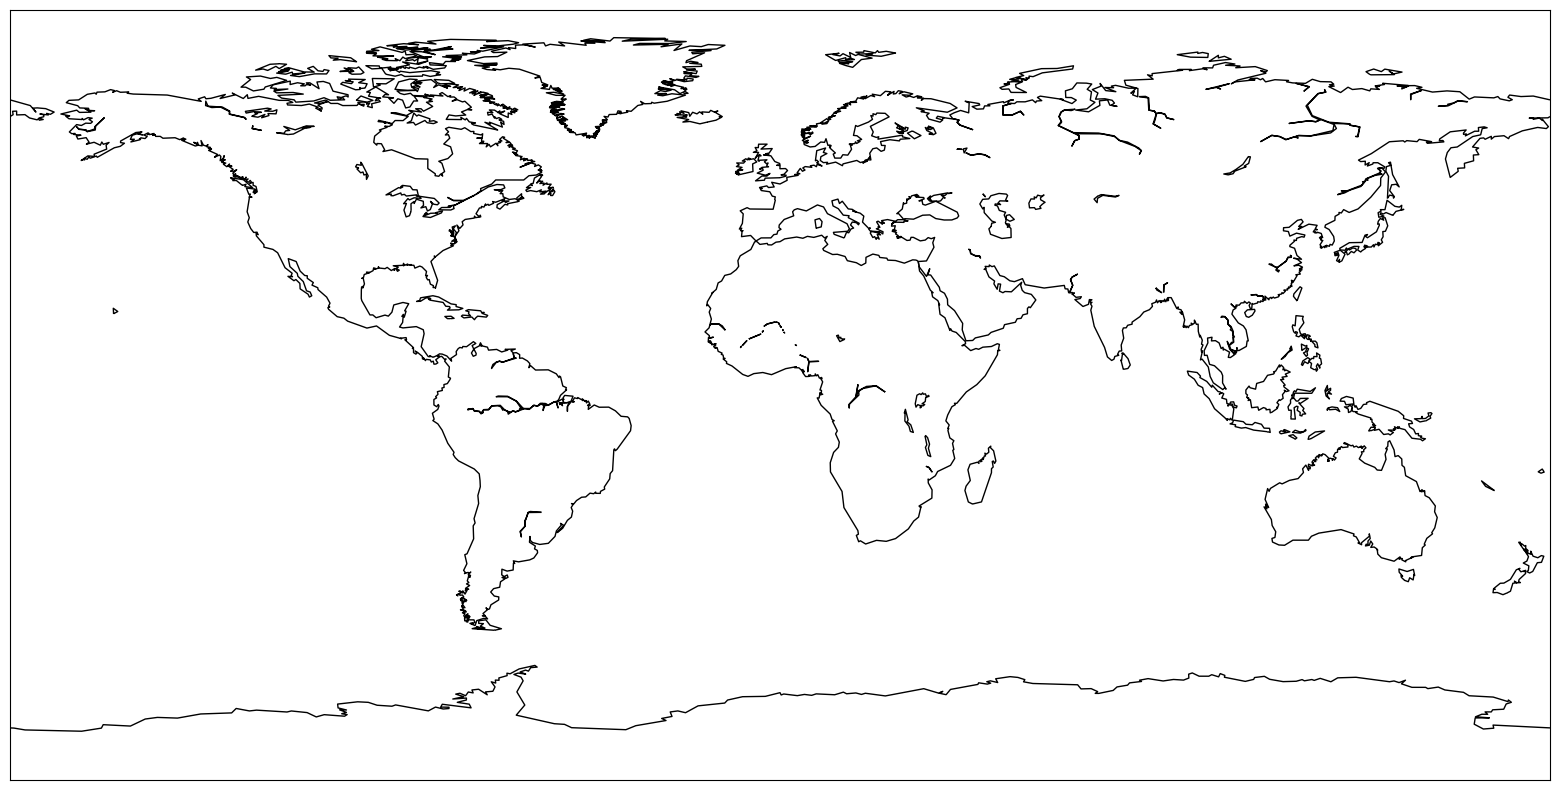

In [17]:
# Visualize the entire dataset
VISUALIZE_AVG_COLORS = True
import glob
import datetime
from tqdm import tqdm
# img_root = "/home/leca5365/Datasets/satclip-s2-temporal-55k/images/"

img_root = "/media/volume/satclip-datasets/Datasets/ts-satclip-s2-1M/"
img_paths = glob.glob(f"{img_root}/**/*.tif", recursive=True)

img_paths = np.random.choice(img_paths, size=100000, replace=False)

fig, ax = plt.subplots(1,1, figsize=(20, 10))

m = Basemap(projection='cyl', resolution='c', ax=ax)
m.drawcoastlines()

doys = []
ts = []
xs = []
ys = []
avg_colors = []

def get_avg_color(path):
    with rasterio.open(path) as f:
        if USE_COLOR_NORMALIZATION_PERCENT:
            low = 0.02*np.max([np.max(f.read(4)), np.max(f.read(3)), np.max(f.read(2))])
            high = 0.98*np.max([np.max(f.read(4)), np.max(f.read(3)), np.max(f.read(2))])

            red_band = ((np.clip(f.read(4), low, high) - low) / (high-low) * 255).astype(np.uint8)
            green_band = ((np.clip(f.read(3), low, high) - low) / (high-low) * 255).astype(np.uint8)
            blue_band = ((np.clip(f.read(2), low, high) - low) / (high-low) * 255).astype(np.uint8)
        else:
            red_band = f.read(4) / 10000.0
            green_band = f.read(3) / 10000.0
            blue_band = f.read(2) / 10000.0

        avg_red = np.mean(red_band)
        avg_green = np.mean(green_band)
        avg_blue = np.mean(blue_band)
    return (avg_red, avg_green, avg_blue)

for img_path in tqdm(img_paths):
    id, x, y, t, tags = get_metadata(img_path)
    dt = datetime.datetime.strptime(t, '%Y-%m-%dT%H:%M:%S.%f+00:00')
    doy = dt.timetuple().tm_yday
    doys.append(doy)
    xs.append(x)
    ys.append(y)
    ts.append(t)
    
    if VISUALIZE_AVG_COLORS:
        avg_colors.append(get_avg_color(img_path))

ax.scatter(xs, ys, s=10, c=doys, cmap='viridis', alpha=0.7) 
# fig.colorbar(fig.gca(), label='Day of Year', ax=ax)
# plt.show()

fig, ax = plt.subplots(1,1, figsize=(20, 10))
ax.hist(doys, bins=365)
ax.set_xlabel('Day of Year')
ax.set_ylabel('Number of Images')
plt.show()

NameError: name 'avg_colors' is not defined

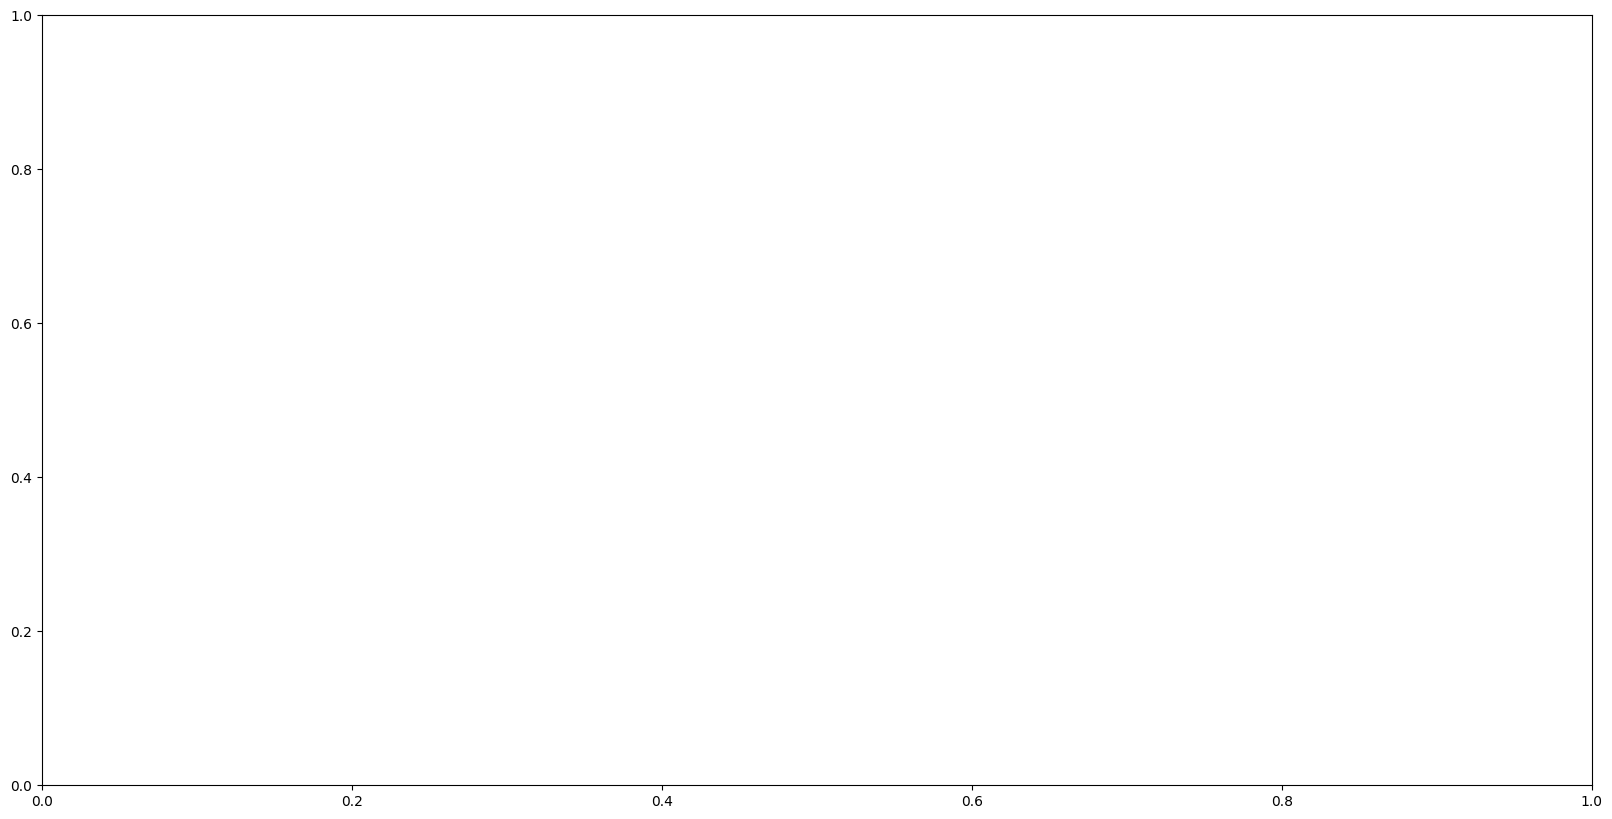

In [9]:
fig, ax = plt.subplots(1,1, figsize=(20, 10))
avg_colors_scaled = np.array([np.array(list(colors)) for colors in avg_colors])/255.0

ax.scatter(xs, ys, s=10, c=avg_colors_scaled, alpha=0.7) 
plt.show()


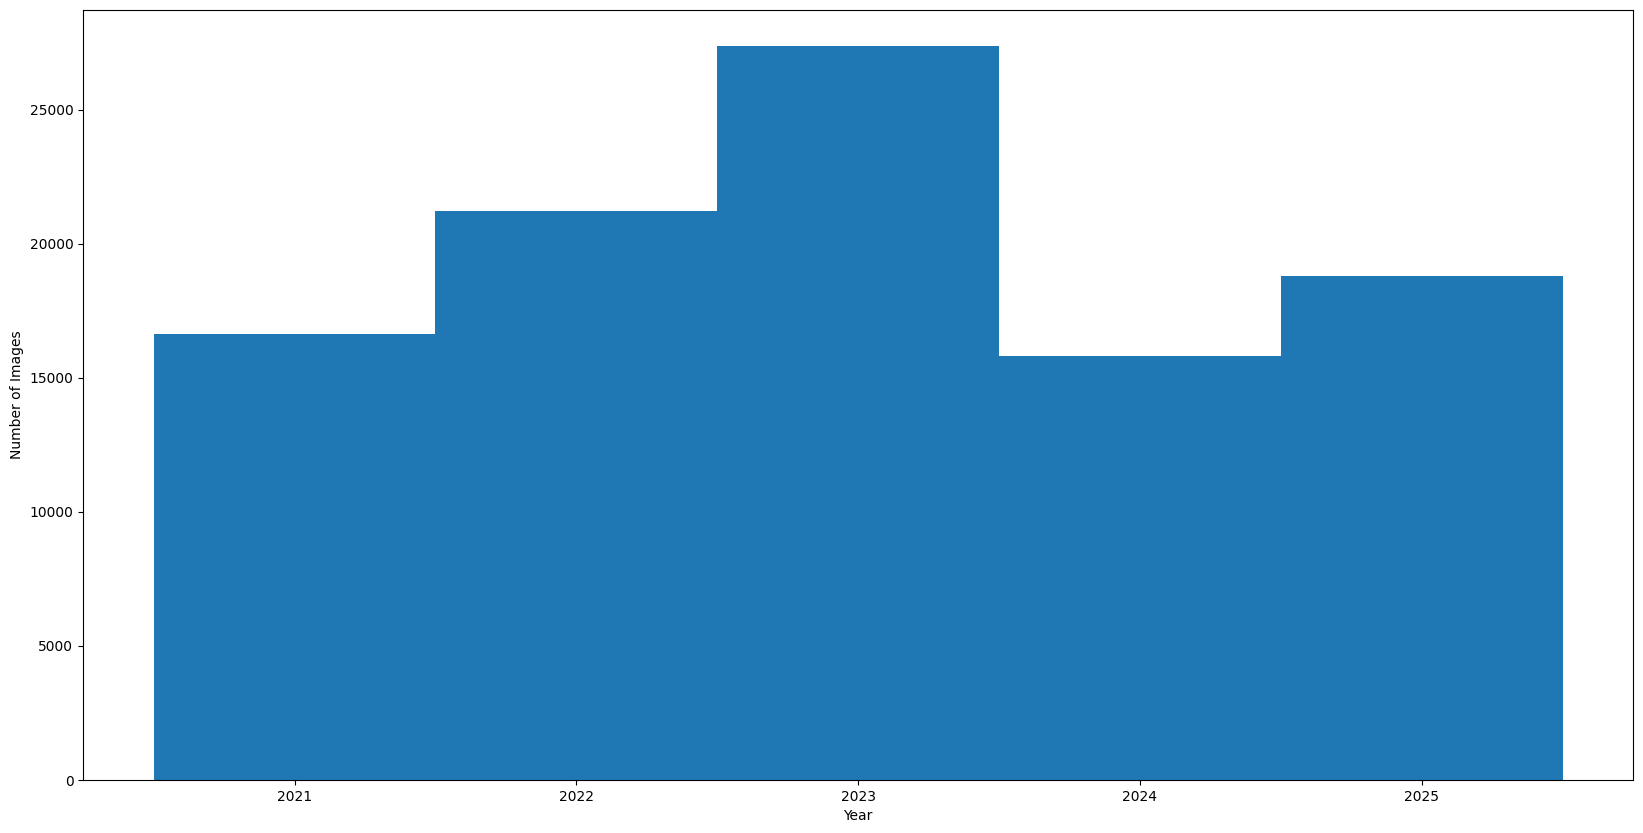

In [13]:
# Plot year distributions
fig, ax = plt.subplots(1,1, figsize=(20, 10))

years = []
for t in ts:
    dt = datetime.datetime.strptime(t, '%Y-%m-%dT%H:%M:%S.%f+00:00')
    year = dt.year
    years.append(year)

ax.hist(years, bins=np.arange(min(years), max(years) + 1) - 0.5)
ax.set_xlabel('Year')
ax.set_ylabel('Number of Images')
plt.show()



In [ ]:
if VISUALIZE_AVG_COLORS:
    df = pd.DataFrame({'d': doys, 't': ts, 'x': xs, 'y': ys, 'path': img_paths, 'avg_color': avg_colors})
else:
    df = pd.DataFrame({'d': doys, 't': ts, 'x': xs, 'y': ys, 'path': img_paths})
print(len(df))

df["t"] = pd.to_datetime(df["t"])
df.tail()
df.to_csv("s2_image_metadata.csv", index=False)


100000


In [7]:
df = pd.read_csv("s2_image_metadata.csv")

In [10]:
df.columns

Index(['d', 't', 'x', 'y', 'path', 'avg_color'], dtype='object')

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (100000,) + inhomogeneous part.

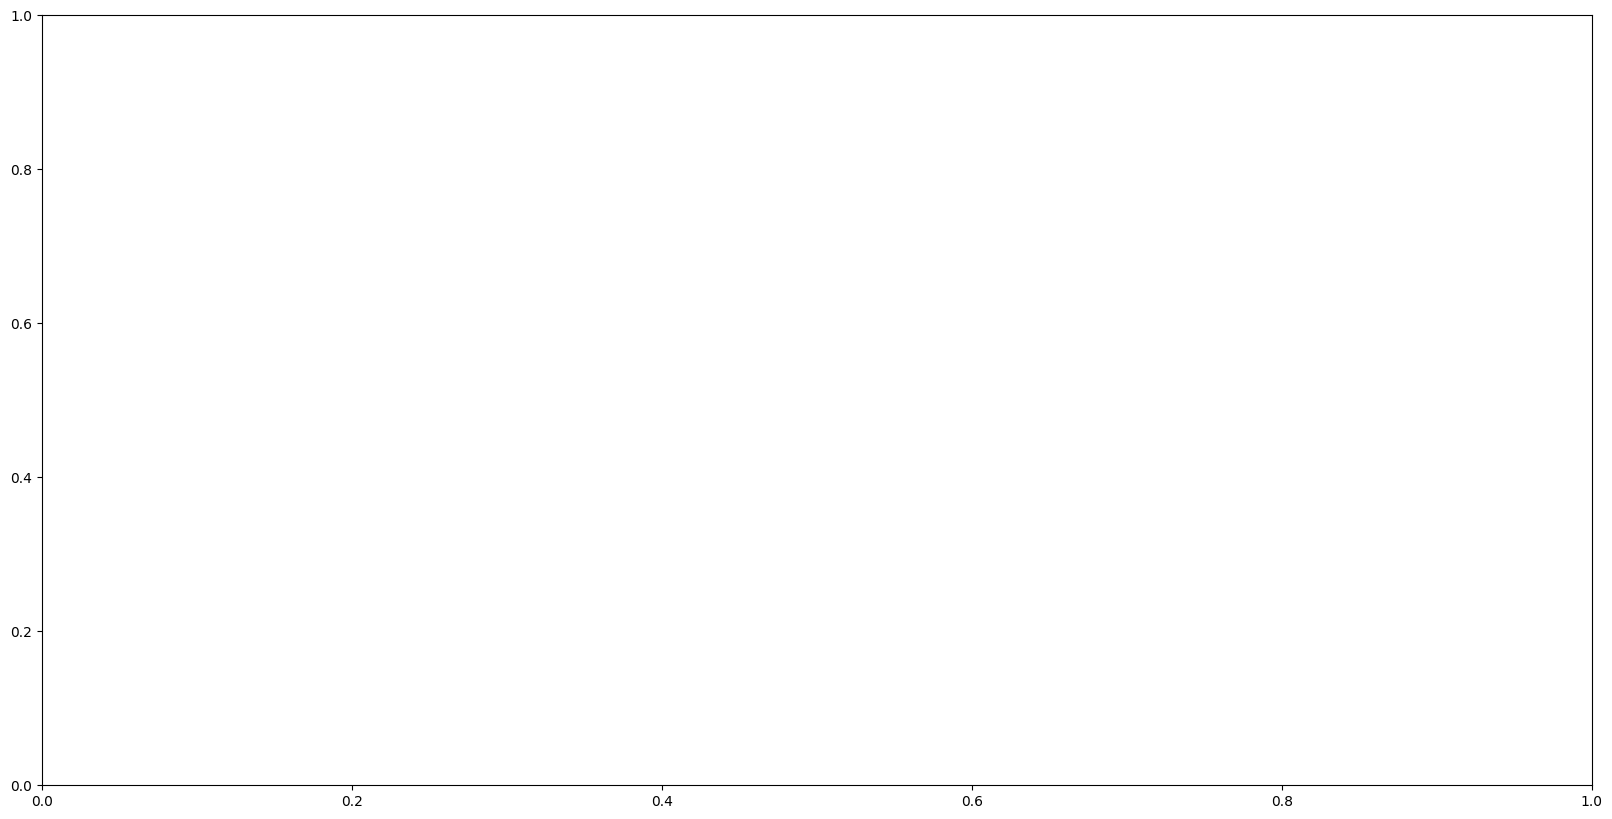

In [11]:
fig, ax = plt.subplots(1,1, figsize=(20, 10))
avg_colors_scaled = np.array([np.array(list(colors)) for colors in df['avg_color']])/255.0

ax.scatter(xs, ys, s=10, c=avg_colors_scaled, alpha=0.7) 
plt.show()

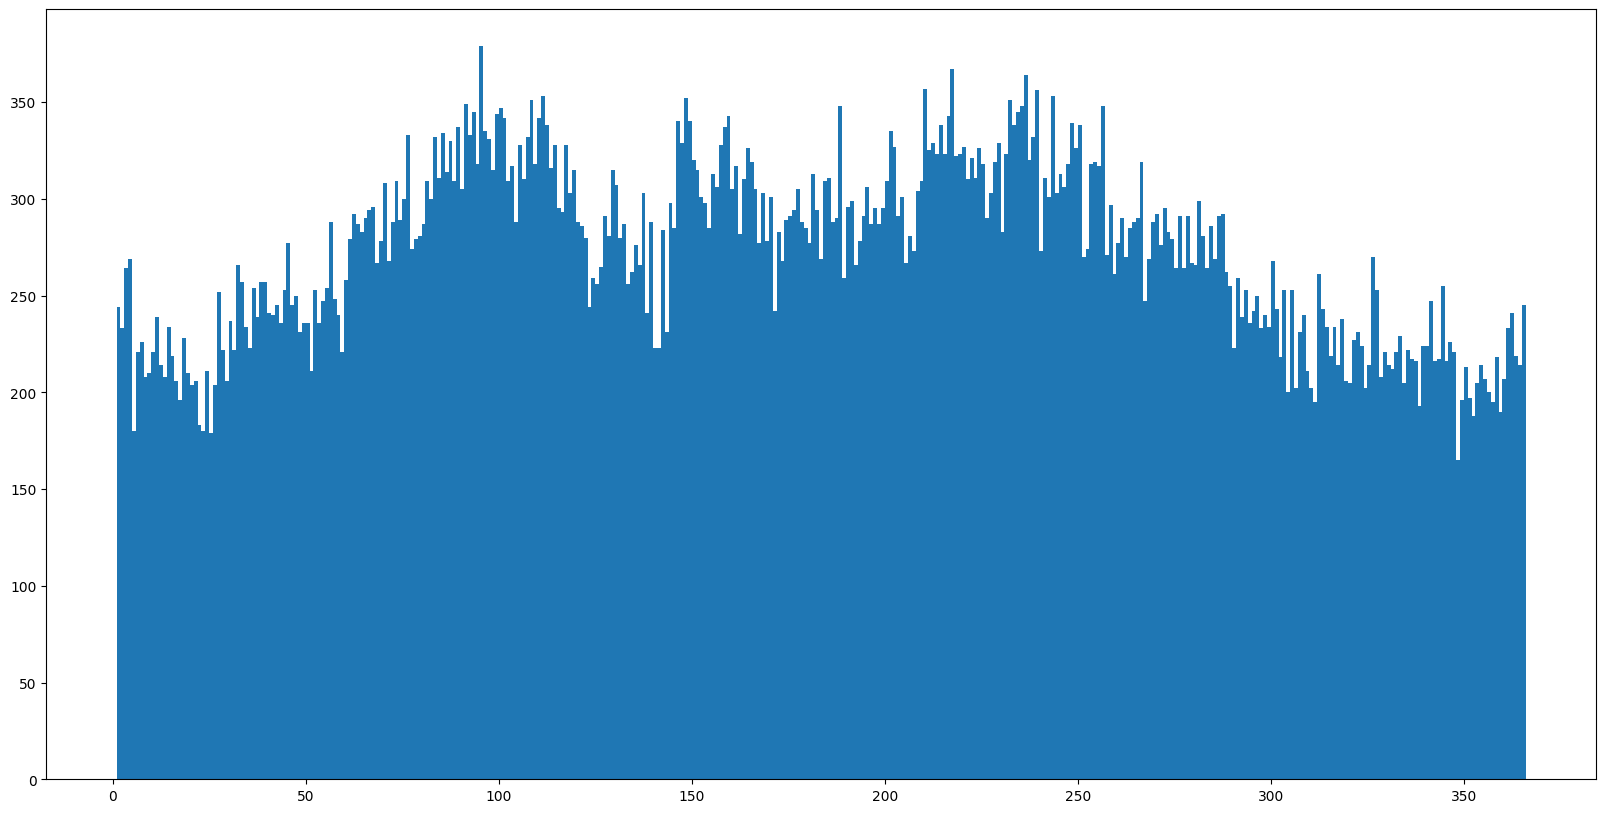

In [8]:
fig, ax = plt.subplots(1,1, figsize=(20, 10))
ax.hist(df["d"], bins=365)
plt.show()

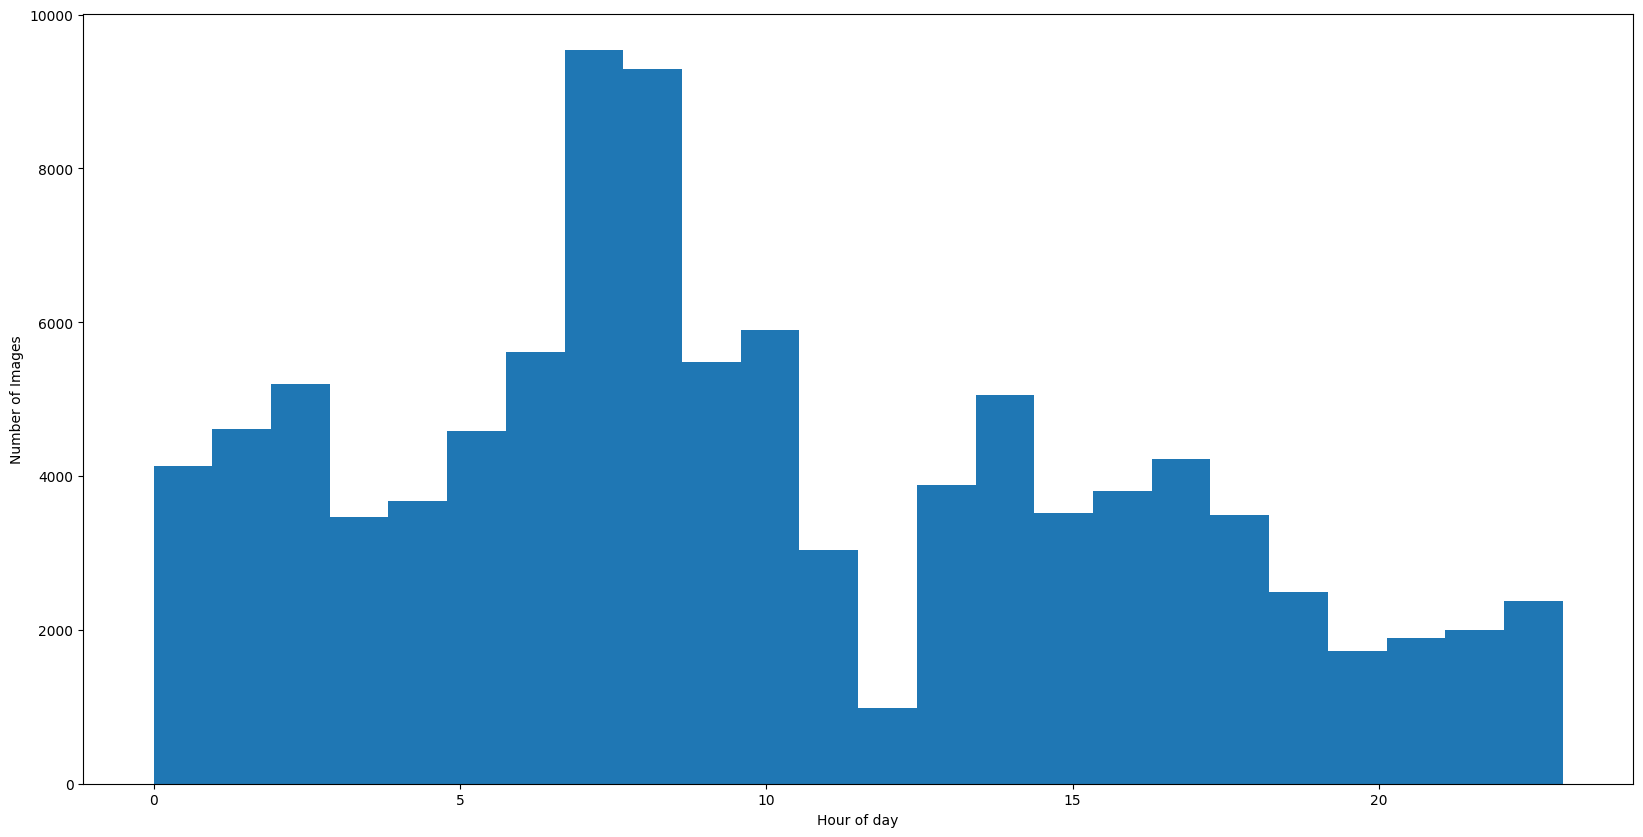

In [16]:
# TODO: transform from UTC to local time
hs = [datetime.datetime.strptime(t, '%Y-%m-%dT%H:%M:%S.%f+00:00').hour for t in df['t']]
fig, ax = plt.subplots(1,1, figsize=(20, 10))
ax.hist(hs, bins=24)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Number of Images')
plt.show()

100%|██████████| 7/7 [00:03<00:00,  2.16it/s]


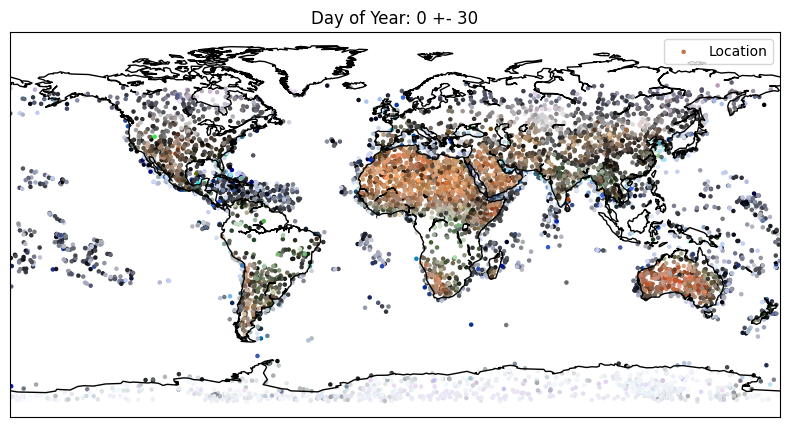

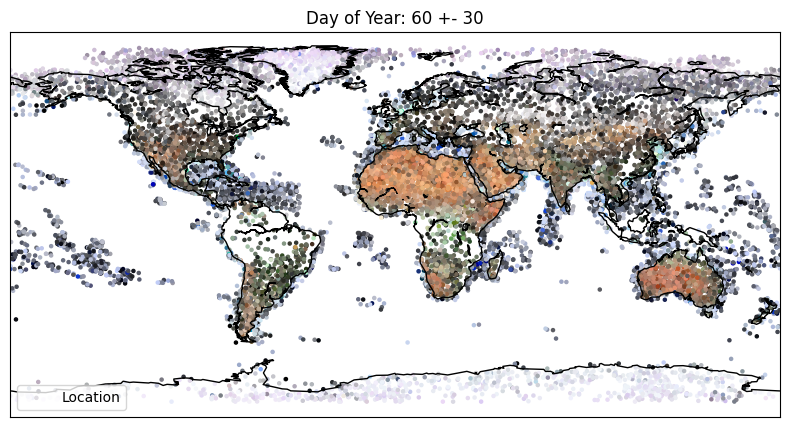

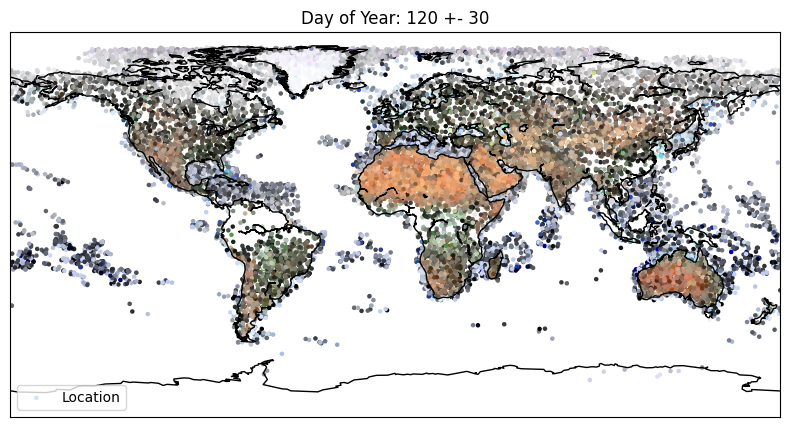

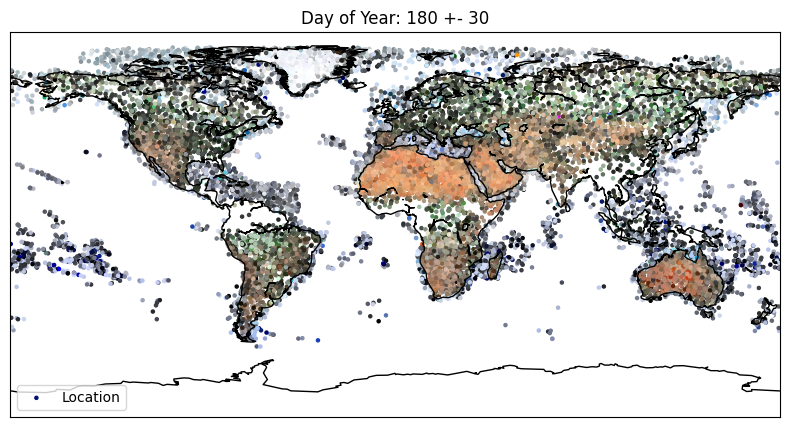

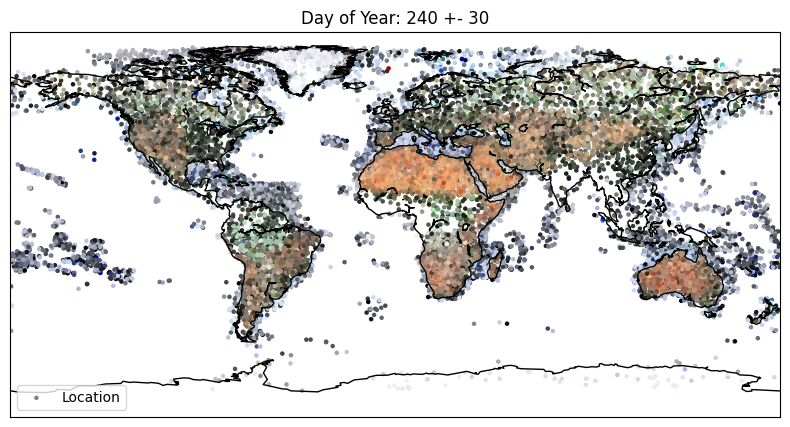

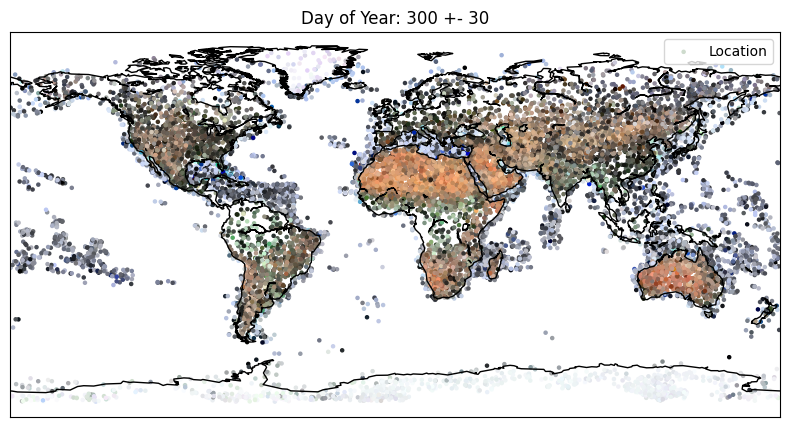

In [ ]:
# Make a gif over time of the dataset
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from mpl_toolkits.axes_grid1 import make_axes_locatable
from PIL import Image
import io
from tqdm import tqdm

frames = []

days_win = 30

for doy in tqdm([0, 60, 120, 180, 240, 300, 360]):
    # Find images within a window of days
    df_window = df[(df['d'] >= doy - days_win) & (df['d'] <= doy + days_win)]

    cs = np.array([np.array(x)/255.0 for x in df_window['avg_color'].values])
    # cs = np.minimum(cs, 1.0)

    # Plot the average colors of the images in this window on the map
    fig, ax = plt.subplots(1,1, figsize=(10, 5))

    m = Basemap(projection='cyl', resolution='c', ax=ax)
    m.drawcoastlines()

    sc = ax.scatter(df_window['x'].values, df_window['y'].values, s=5, c=cs, label="Location")
    ax.set_title(f"Day of Year: {doy} +- {days_win}")
    ax.legend()

    buf = io.BytesIO()
    fig.savefig(buf, format='png')
    buf.seek(0)
    frames.append(Image.open(buf))


# Save as GIF
frames[0].save('s2_temporal_dataset_evolution.gif', format='GIF', append_images=frames[1:], save_all=True, duration=500, loop=0)

100%|██████████| 13/13 [00:00<00:00, 15.37it/s]


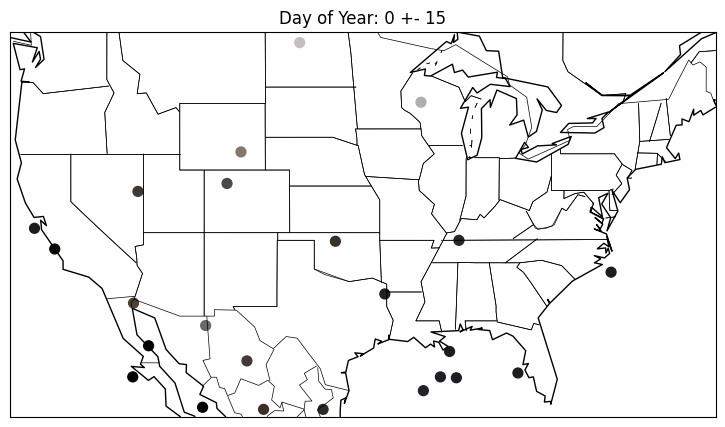

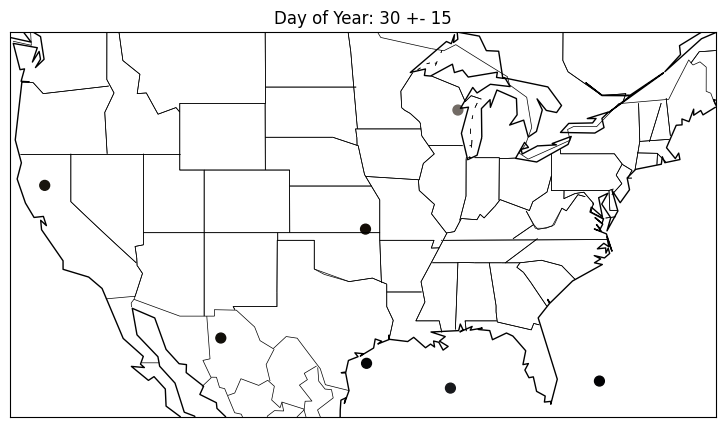

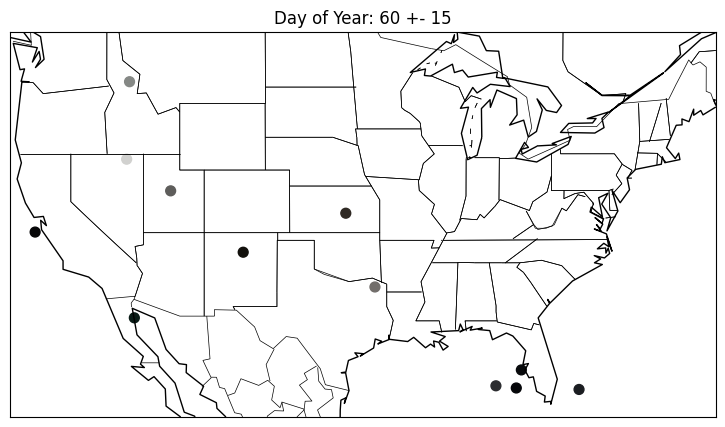

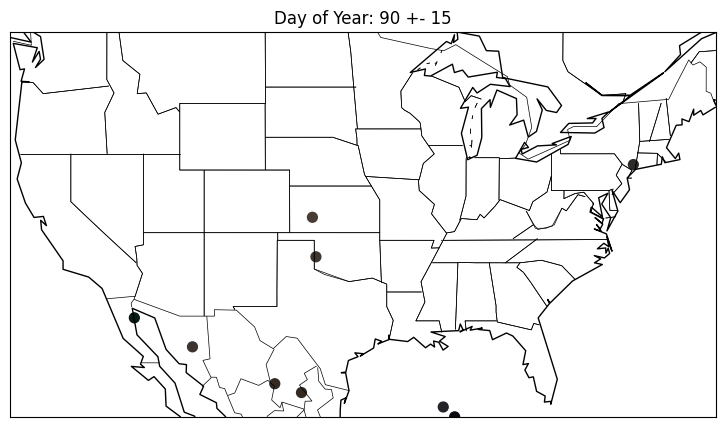

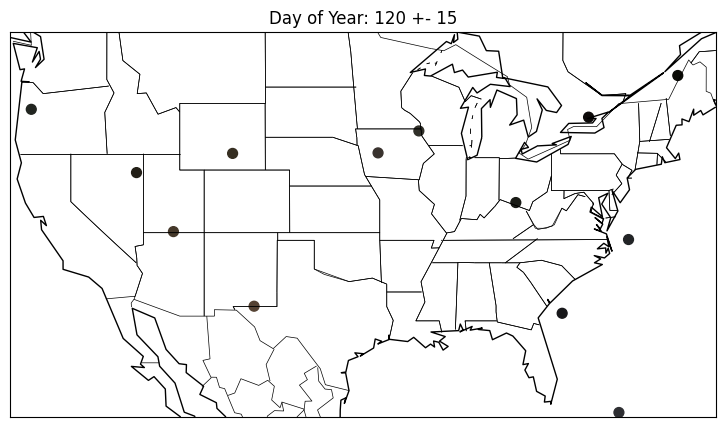

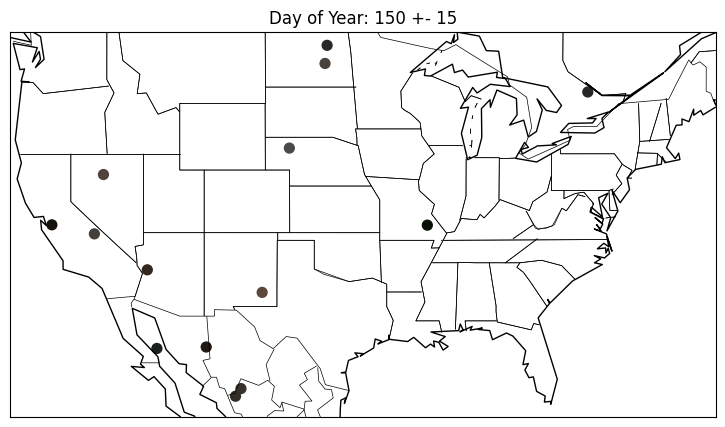

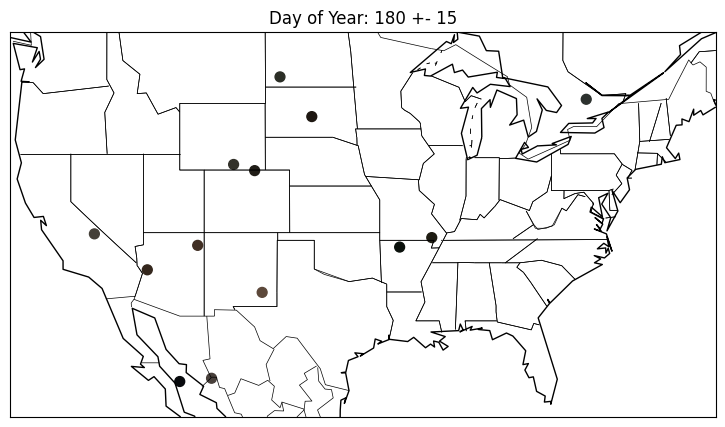

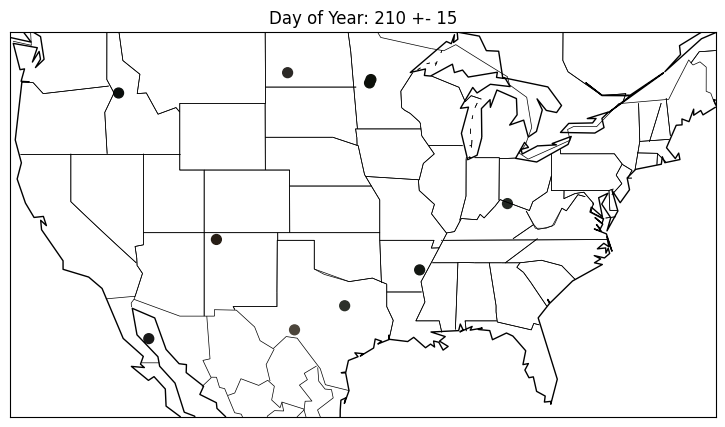

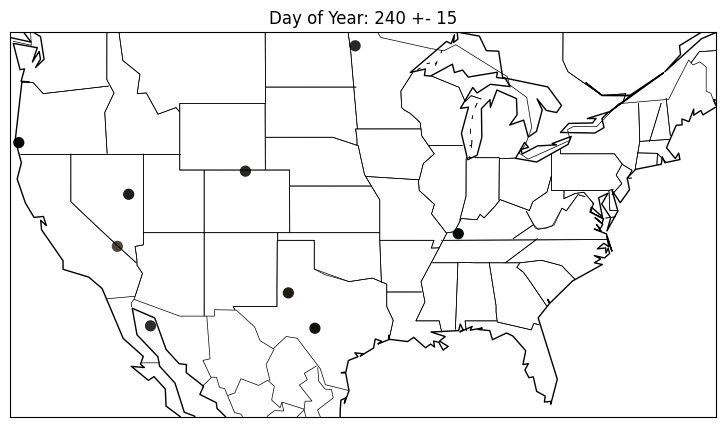

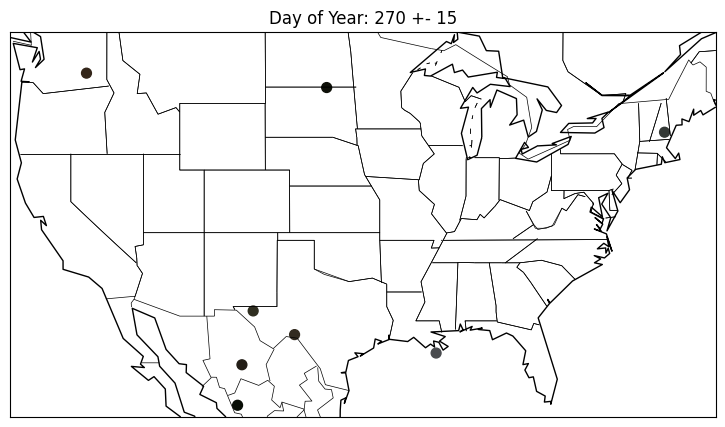

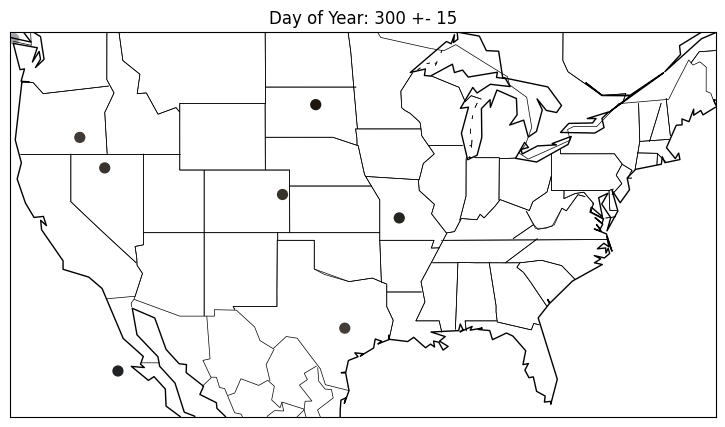

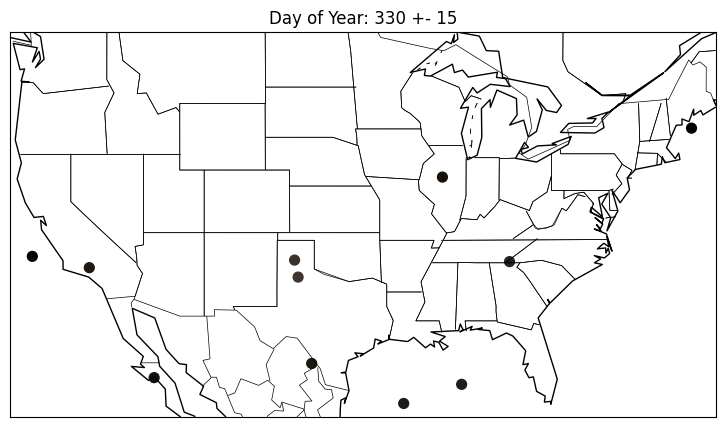

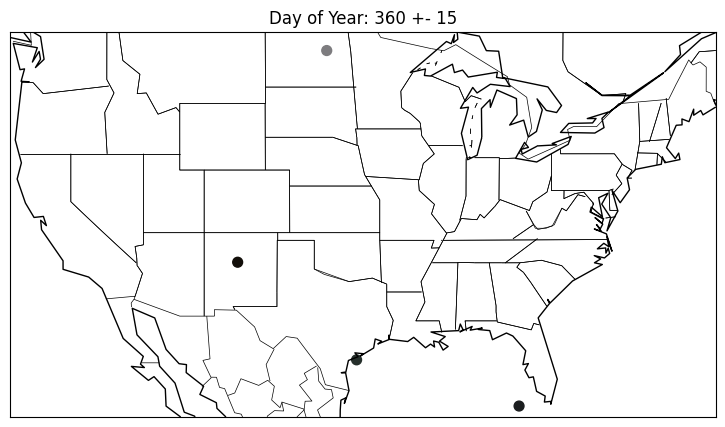

In [ ]:
# Plot smaller scale views
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from mpl_toolkits.axes_grid1 import make_axes_locatable
from PIL import Image
import io
from tqdm import tqdm

# For the continental United States
lons = [-125, -67]
lats = [24, 49]
days_win = 15

frames = []

for doy in tqdm(range(0,365, 30)):
    # Find images within a window of days
    df_window = df[(df['d'] >= doy - days_win) & 
                   (df['d'] <= doy + days_win) & 
                   (df['x'] <= lons[1]) &
                   (df['x'] >= lons[0]) & 
                   (df['y'] >= lats[0]) & 
                   (df['y'] <= lats[1]) ]
    

    cs = np.array([np.array(x)/255.0 for x in df_window['avg_color'].values])
    # cs = np.minimum(cs, 1.0)

    # Plot the average colors of the images in this window on the map
    fig, ax = plt.subplots(1,1, figsize=(10, 5))

    m = Basemap(projection='merc', 
                lon_0=0,
                llcrnrlat=lats[0], 
                llcrnrlon=lons[0],
                urcrnrlat=lats[1],
                urcrnrlon=lons[1],
                resolution='c', 
                ax=ax)
    m.drawcoastlines()
    m.drawcountries()
    m.drawstates()
    x, y = m(df_window['x'].values, df_window['y'].values)

    sc = ax.scatter(x, y, s=50, c=cs, label="Location")
    ax.set_title(f"Day of Year: {doy} +- {days_win}")
    # ax.legend()

    buf = io.BytesIO()
    fig.savefig(buf, format='png')
    buf.seek(0)
    frames.append(Image.open(buf))

# Save as GIF
frames[0].save('s2_temporal_dataset_finegrain_evolution.gif', format='GIF', append_images=frames[1:], save_all=True, duration=500, loop=0)



In [ ]:
print(df_window['path'].iloc[0])


/home/leca5365/Datasets/satclip-s2-temporal-55k/images/patch_10038.tif


In [ ]:
import pandas as pd
import os
from tqdm import tqdm

# Iterate through dataset to check for corrupted files
CHECK_MIN_FILESIZE = 1000  # in bytes
n_skipped_files = 0

# root = "/mnt/rolf-datastore/home/leca5365/Datasets/satclip-s2-100k"
root = "/mnt/rolf-datastore/home/leca5365/Datasets/satclip"

index_fn = "index.csv"

df = pd.read_csv(os.path.join(root, index_fn))
filenames = []
points = []

n_skipped_files = 0
n_corrupted_files = 0
for i in tqdm(range(df.shape[0])):
    filename = os.path.join(root, "images", df.iloc[i]["fn"])
    
    # Useful for training subsets
    if os.path.exists(filename) == False:
        n_skipped_files += 1
        continue

    if os.path.getsize(filename) < CHECK_MIN_FILESIZE:
        n_skipped_files += 1
        continue
    
    # Ensure it is valid raster
    try:
        
        with rasterio.open(filename) as f:
            data = f.read().astype(np.float32)
    except:
        n_skipped_files += 1
        n_corrupted_files += 1
        print(f"Corrupted file: {filename}")
        continue

    filenames.append(filename)
    points.append(
        (df.iloc[i]["lon"], df.iloc[i]["lat"])
    )

print(f"Number of skipped files: {n_skipped_files}")